In [1]:
import duckdb
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Using a relative path to reach the data from the notebooks/ folder
con = duckdb.connect('../data/processed/biocascade.db')
df = con.execute("SELECT * FROM raw_patient_data").df()

print(f"✅ Loaded {len(df)} patients for validation.")
df.head()

✅ Loaded 5533 patients for validation.


,SEQN,age,gender,systolic_bp,diastolic_bp,hba1c,triglycerides,serum_creatinine
0,93705,66,2,NaN,NaN,6.2,95.0,166.0
1,93706,18,1,112.0,74.0,5.2,92.0,114.0
2,93708,66,2,NaN,NaN,6.2,72.0,347.0
3,93709,75,2,120.0,66.0,6.3,132.0,63.0
4,93711,56,1,108.0,68.0,5.7,59.0,120.0


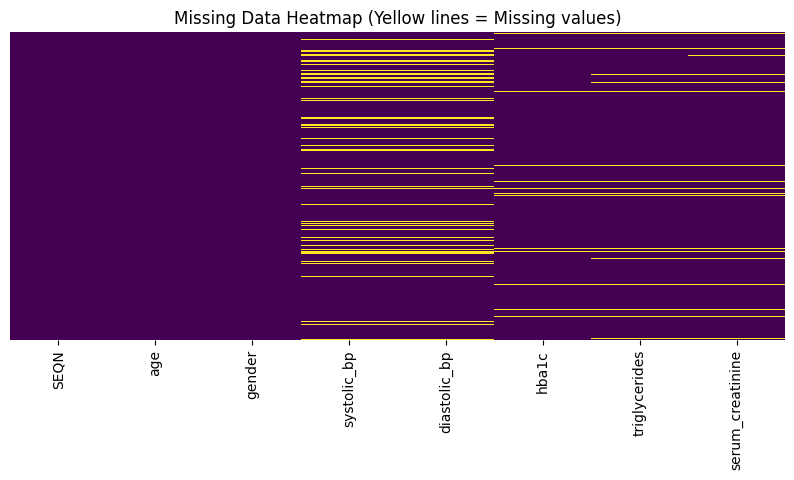

🔍 Missing Value Counts:
SEQN                  0
age                   0
gender                0
systolic_bp         634
diastolic_bp        634
hba1c               272
triglycerides       381
serum_creatinine    382
dtype: int64


In [2]:
# Visualize missing data locations
plt.figure(figsize=(10, 4))
sns.heatmap(df.isnull(), cbar=False, yticklabels=False, cmap='viridis')
plt.title("Missing Data Heatmap (Yellow lines = Missing values)")
plt.show()

# Precise count of missing values per column
print("🔍 Missing Value Counts:")
print(df.isnull().sum())

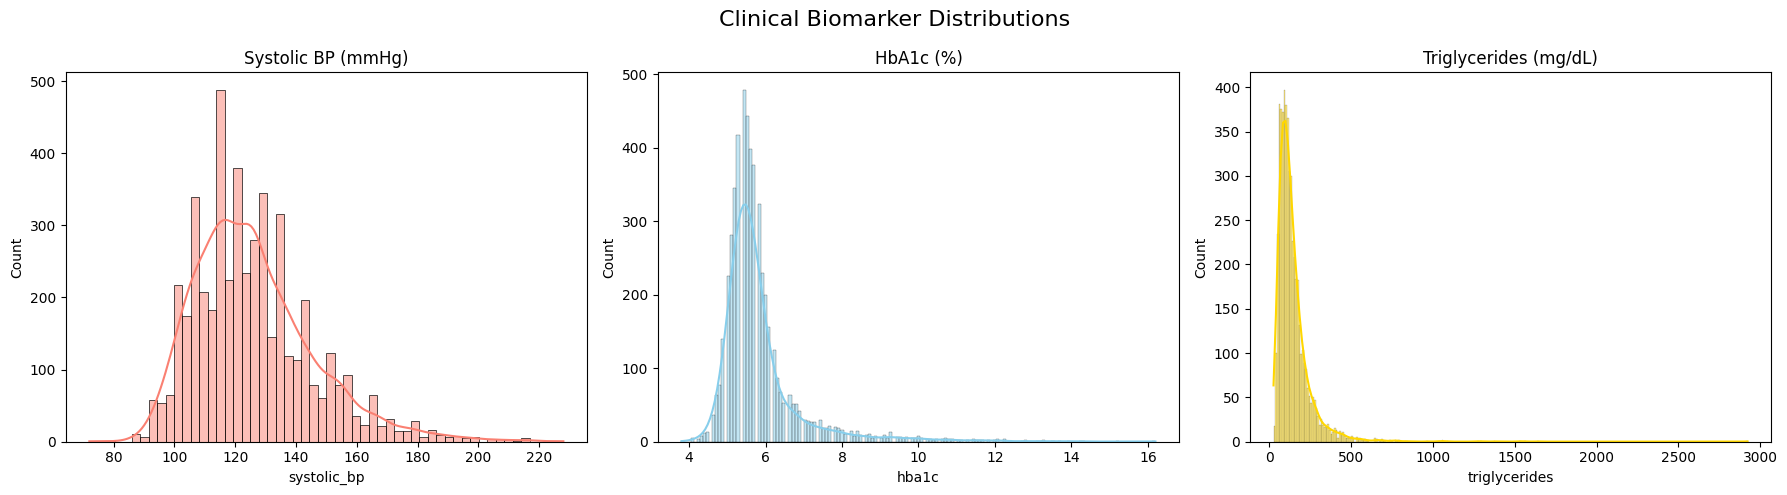

In [3]:
# Setting up a multi-plot figure
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plotting distributions for key biomarkers
sns.histplot(df['systolic_bp'].dropna(), kde=True, ax=axes[0], color='salmon').set_title('Systolic BP (mmHg)')
sns.histplot(df['hba1c'].dropna(), kde=True, ax=axes[1], color='skyblue').set_title('HbA1c (%)')
sns.histplot(df['triglycerides'].dropna(), kde=True, ax=axes[2], color='gold').set_title('Triglycerides (mg/dL)')

plt.suptitle("Clinical Biomarker Distributions", fontsize=16)
plt.tight_layout()
plt.show()

In [ ]:
# Correlation Heatmap to see biological relationships
plt.figure(figsize=(10, 8))

# Dropping SEQN as it's a random ID, not a biological marker
corr = df.drop(columns=['SEQN']).corr() 

# Plotting with a 'coolwarm' palette (Red = Positive, Blue = Negative)
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Biomarker Correlation Matrix")
plt.show()